# Notebook 2: Stress Indicators and Siting Suitability

This notebook builds a **composite siting suitability index** for data center development 
across Washington State using three publicly available stress indicator layers. The goal is 
not to select sites — it is to show *which communities and ecosystems bear the hidden costs* 
of the current siting pattern, and where better alternatives exist.

**The three indicators:**

1. **Transmission Proximity** — distance to the nearest high-voltage (≥100kV) transmission line.
   Siting decisions are primarily driven by grid access; far from lines means higher interconnection 
   cost and timeline.
   ([WA DOR Data Center Workgroup Preliminary Report, Dec 2025](https://dor.wa.gov/sites/default/files/2025-12/2025DataCntrWrkgrpPrelimReport.pdf))

2. **Community Burden (EJScreen)** — EPA's Environmental Justice Index per census tract, measuring 
   which communities already carry disproportionate environmental and demographic burdens. Siting 
   in high-burden areas compounds existing inequities and is the primary political liability of the 
   current pattern. When Grant County PUD customers absorb grid upgrade costs for hyperscale 
   buildout, lower-income agricultural communities pay the bill.
   ([NPR / OPB, Aug 2025](https://www.npr.org/2025/08/17/nx-s1-5501579/washington-hydropower-data-center-boom-sustainability-climate-change))

3. **Water Availability** — 30-year mean annual precipitation (1991–2020) as a proxy for cooling 
   water availability. Eastern WA is semi-arid (~200–400 mm/yr); western WA receives 800–3,000 mm/yr. 
   A medium data center uses ~110 million gallons of water per year; large facilities use up to 
   1.8 billion gallons — equivalent to the annual usage of a city of 10,000–50,000.
   ([NPR / OPB, Aug 2025](https://www.npr.org/2025/08/17/nx-s1-5501579/washington-hydropower-data-center-boom-sustainability-climate-change)) 
   Precipitation data from [Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api) 
   (30-year archive, no API key required, free for non-commercial use).

---

**Note on backlash quantification:** We do not directly score 'backlash' — that is an outcome, 
not a cause. Instead we score the *inputs* to backlash: water stress, community burden, and grid 
saturation. These proxy measures are quantifiable, citable, and defensible in a policy context. 
National data shows water use is cited in >40% of contested data center projects; 25 projects 
were canceled due to local opposition in 2025, up from 6 in 2024.
([Heatmap News, 2025](https://heatmap.news/politics/data-center-cancellations-2025))

## Data Sources

| Layer | Source | License | Access |
|---|---|---|---|
| Transmission lines | [OSM / Overpass API](https://overpass-api.de/) (Notebook 1) | ODbL | Cached from Notebook 1 |
| Community burden | [US Census ACS 5-Year Estimates 2022](https://www.census.gov/data/developers/data-sets/acs-5year.html) (poverty + minority rates, replicating EJScreen Demographic Index) | Public domain | Census REST API |
| Census tract boundaries | [Census TIGER/Line 2022](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html) | Public domain | Direct download |
| Precipitation normals | [Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api) (ERA5 reanalysis, 1991-2020) | CC-BY 4.0 | REST API, no key |

In [1]:
import io
import time
import zipfile
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import requests
from shapely.geometry import box, Point

warnings.filterwarnings('ignore')

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
CRS = 'EPSG:4326'
CRS_PROJ = 'EPSG:32610'

# Load layers from Notebook 1
wa = gpd.read_file(RAW / 'wa_state.geojson')
dc_gdf = gpd.read_file(RAW / 'datacenters.geojson')
tx_gdf = gpd.read_file(RAW / 'transmission_wa.geojson')

print(f'WA boundary: {len(wa)} feature(s)')
print(f'Data centers: {len(dc_gdf)}')
print(f'Transmission lines: {len(tx_gdf)}')

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


WA boundary: 1 feature(s)
Data centers: 19
Transmission lines: 6127


## 1. Analysis Grid

A 0.15-degree fishnet (~14 km at WA latitudes) over the Washington State extent, clipped to 
the state boundary. Each cell receives a normalized score (0–1) on each indicator, then a 
weighted composite suitability score.

In [2]:
def create_fishnet(extent_gdf, cell_size_deg=0.15):
    xmin, ymin, xmax, ymax = extent_gdf.total_bounds
    xs = np.arange(xmin, xmax + cell_size_deg, cell_size_deg)
    ys = np.arange(ymin, ymax + cell_size_deg, cell_size_deg)
    cells = [box(x, y, x + cell_size_deg, y + cell_size_deg)
             for x in xs[:-1] for y in ys[:-1]]
    grid = gpd.GeoDataFrame({'geometry': cells}, crs=CRS)
    wa_union = extent_gdf.geometry.unary_union
    grid = grid[grid.centroid.within(wa_union)].reset_index(drop=True)
    grid['cell_id'] = range(len(grid))
    return grid

grid = create_fishnet(wa, cell_size_deg=0.15)
print(f'Grid: {len(grid)} cells at 0.15 deg (~14 km)')

Grid: 974 cells at 0.15 deg (~14 km)


## 2. Layer 1: Transmission Proximity

Distance from each grid cell centroid to the nearest high-voltage transmission line 
(OSM `power=line` with voltage ≥100kV, from Notebook 1). Proximity to high-voltage 
transmission is the **single most important factor** in data center site selection — 
inadequate grid access is cited as the binding constraint in the Quincy corridor.
([WA DOR Workgroup Report, Dec 2025](https://dor.wa.gov/sites/default/files/2025-12/2025DataCntrWrkgrpPrelimReport.pdf))

**Score convention:** 1.0 = adjacent to a transmission line (ideal); 0.0 = farthest cell from any line.

In [3]:
tx_proj = tx_gdf.to_crs(CRS_PROJ)
tx_union = tx_proj.geometry.unary_union

grid_proj = grid.to_crs(CRS_PROJ)
centroids_proj = list(grid_proj.geometry.centroid)

print('Computing transmission proximity distances...')
grid['tx_dist_m'] = [tx_union.distance(pt) for pt in centroids_proj]

max_dist = grid['tx_dist_m'].max()
grid['tx_score'] = 1.0 - (grid['tx_dist_m'] / max_dist)

print(f'Max distance to transmission: {max_dist/1000:.1f} km')
print(f'Transmission score — mean: {grid["tx_score"].mean():.3f}, std: {grid["tx_score"].std():.3f}')

Computing transmission proximity distances...
Max distance to transmission: 51.3 km
Transmission score — mean: 0.795, std: 0.204


## 3. Layer 2: Community Burden (Census ACS Demographic Index)

We compute a **Demographic Index** — weighted average of poverty rate and minority rate —
from [US Census Bureau American Community Survey 5-Year Estimates (2022)](https://www.census.gov/data/developers/data-sets/acs-5year.html)
at the census tract level for Washington State.

This replicates the core formula used by
[EPA EJScreen's Demographic Index](https://www.epa.gov/ejscreen/overview-demographic-indicators-ejscreen):
average of percent low-income and percent people of color per tract. Census tract boundaries
from [Census TIGER/Line 2022](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html).

ACS variables:
- `B17001_001E` / `B17001_002E` — total population / below poverty → **poverty rate**
- `B02001_001E` / `B02001_002E` — total population / white alone → **minority rate** = 1 − (white/total)

Demographic Index = average(poverty rate, minority rate).
API key read from snotrac project `.env` (same Census key, no re-registration required).

**Score convention:** 1.0 = lowest community burden; 0.0 = highest. Inverted so higher = better siting.

In [4]:
import os

acs_path = RAW / 'acs_demog_wa.csv'

if not acs_path.exists():
    census_key = None
    env_path = Path('/home/simonhans/coding/snotrac/.env')
    if env_path.exists():
        for line in env_path.read_text().splitlines():
            if line.startswith('CENSUS_API_KEY'):
                census_key = line.split('=', 1)[1].strip()
    if not census_key:
        census_key = os.environ.get('CENSUS_API_KEY')
    if not census_key:
        raise RuntimeError('Census API key not found.')
    print(f'Using Census API key: ...{census_key[-6:]}')

    params = {
        'get': 'NAME,B17001_001E,B17001_002E,B02001_001E,B02001_002E',
        'for': 'tract:*',
        'in': 'state:53',
        'key': census_key
    }
    r = requests.get('https://api.census.gov/data/2022/acs/acs5', params=params, timeout=60)
    r.raise_for_status()
    rows = r.json()
    df = pd.DataFrame(rows[1:], columns=rows[0])
    for col in ['B17001_001E', 'B17001_002E', 'B02001_001E', 'B02001_002E']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['GEOID'] = df['state'].str.zfill(2) + df['county'].str.zfill(3) + df['tract'].str.zfill(6)
    df['poverty_rate'] = (df['B17001_002E'] / df['B17001_001E']).clip(0, 1)
    df['minority_rate'] = (1 - df['B02001_002E'] / df['B02001_001E']).clip(0, 1)
    df['demog_index'] = (df['poverty_rate'] + df['minority_rate']) / 2
    df.to_csv(acs_path, index=False)
    print(f'Saved {len(df)} WA census tracts.')
else:
    df = pd.read_csv(acs_path, dtype={'GEOID': str})
    print(f'Loaded {len(df)} WA census tracts from cache.')

print(f'Demographic index range: {df["demog_index"].min():.3f} - {df["demog_index"].max():.3f}')

Loaded 1784 WA census tracts from cache.
Demographic index range: 0.000 - 0.611


In [5]:
tract_path = RAW / 'wa_tracts.geojson'

if not tract_path.exists():
    print('Downloading WA census tract boundaries...')
    url = 'https://www2.census.gov/geo/tiger/TIGER2022/TRACT/tl_2022_53_tract.zip'
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(RAW / 'wa_tracts_shp')
    tracts = gpd.read_file(RAW / 'wa_tracts_shp' / 'tl_2022_53_tract.shp').to_crs(CRS)
    tracts.to_file(tract_path, driver='GeoJSON')
    print(f'Saved {len(tracts)} census tracts.')
else:
    tracts = gpd.read_file(tract_path)

tracts['GEOID'] = tracts['GEOID'].astype(str).str.zfill(11)
df['GEOID'] = df['GEOID'].astype(str).str.zfill(11)

ej_gdf = tracts[['GEOID', 'geometry']].merge(
    df[['GEOID', 'demog_index']], on='GEOID', how='left'
)

grid_pts = gpd.GeoDataFrame(
    {'cell_id': grid['cell_id']},
    geometry=grid.geometry.centroid, crs=CRS
)
joined = gpd.sjoin(
    grid_pts, ej_gdf[['GEOID', 'demog_index', 'geometry']],
    how='left', predicate='within'
)
burden_by_cell = joined.groupby('cell_id')['demog_index'].mean()
grid['demog_burden'] = grid['cell_id'].map(burden_by_cell)

q01, q99 = grid['demog_burden'].quantile([0.01, 0.99])
grid['ej_score'] = 1.0 - ((grid['demog_burden'] - q01) / (q99 - q01)).clip(0, 1)
n_missing = grid['ej_score'].isna().sum()
grid['ej_score'] = grid['ej_score'].fillna(grid['ej_score'].median())

print(f'EJ score computed. {n_missing} cells filled with median.')
print(f'EJ score range: {grid["ej_score"].min():.3f} - {grid["ej_score"].max():.3f}')

EJ score computed. 35 cells filled with median.
EJ score range: 0.000 - 1.000


## 4. Layer 3: Water Availability

Annual precipitation (30-year mean, 1991–2020) from the 
[Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api), 
sourced from ERA5 reanalysis. Precipitation is used as a proxy for available water for 
cooling: semi-arid eastern WA (200–400 mm/yr) is under far greater stress than western WA 
(800–3,000 mm/yr), where ample rainfall exists.

This is a simplified proxy — a production siting tool would use watershed-level water 
allocation data (e.g., [WRI Aqueduct 3.0](https://www.wri.org/data/aqueduct-water-risk-atlas) 
or Washington Department of Ecology water rights records) to directly measure how much 
unallocated water remains in each basin. The Columbia Basin in Grant County is essentially 
fully allocated — the PUD's own administrator has stated that water and power are 'maxed out.'
([NPR / OPB, Aug 2025](https://www.npr.org/2025/08/17/nx-s1-5501579/washington-hydropower-data-center-boom-sustainability-climate-change))

Sampled on a coarse grid, then **IDW-interpolated** to the 0.15-degree analysis grid.

**Score convention:** 1.0 = highest precipitation (most available water); 0.0 = driest.

In [6]:
precip_path = RAW / 'wa_precip_coarse.csv'

if not precip_path.exists():
    print('Fetching 30-year precipitation normals from Open-Meteo (1991-2020)...')
    wa_bounds = wa.total_bounds
    wa_union = wa.geometry.unary_union
    
    sample_lats = np.linspace(wa_bounds[1] + 0.4, wa_bounds[3] - 0.2, 7)
    sample_lons = np.linspace(wa_bounds[0] + 0.4, wa_bounds[2] - 0.2, 11)
    
    records = []
    for lat in sample_lats:
        for lon in sample_lons:
            if not wa_union.contains(Point(lon, lat)):
                continue
            try:
                params = {
                    'latitude': round(lat, 2),
                    'longitude': round(lon, 2),
                    'start_date': '1991-01-01',
                    'end_date': '2020-12-31',
                    'daily': 'precipitation_sum',
                    'timezone': 'UTC'
                }
                r = requests.get('https://archive-api.open-meteo.com/v1/archive',
                                 params=params, timeout=30)
                r.raise_for_status()
                vals = [v for v in r.json()['daily']['precipitation_sum'] if v is not None]
                ann_mm = sum(vals) / 30.0
                records.append({'lat': lat, 'lon': lon, 'ann_precip_mm': ann_mm})
                time.sleep(0.05)
            except Exception as e:
                print(f'  Skipped ({lat:.2f},{lon:.2f}): {e}')
    
    precip_df = pd.DataFrame(records)
    precip_df.to_csv(precip_path, index=False)
    print(f'Saved {len(precip_df)} precipitation sample points.')
else:
    precip_df = pd.read_csv(precip_path)
    print(f'Loaded {len(precip_df)} cached precipitation points.')

print(f'Annual precip range: {precip_df["ann_precip_mm"].min():.0f} - {precip_df["ann_precip_mm"].max():.0f} mm/yr')

Loaded 23 cached precipitation points.
Annual precip range: 212 - 2654 mm/yr


In [7]:
def idw(src_lats, src_lons, src_vals, tgt_lats, tgt_lons, power=2):
    """Inverse distance weighting interpolation."""
    results = []
    for lat, lon in zip(tgt_lats, tgt_lons):
        dists = np.sqrt((src_lats - lat)**2 + (src_lons - lon)**2)
        dists = np.maximum(dists, 1e-10)
        w = 1.0 / dists**power
        results.append(float(np.sum(w * src_vals) / np.sum(w)))
    return results

centroids = grid.geometry.centroid
tgt_lats = np.array([p.y for p in centroids])
tgt_lons = np.array([p.x for p in centroids])

grid['ann_precip_mm'] = idw(
    precip_df['lat'].values,
    precip_df['lon'].values,
    precip_df['ann_precip_mm'].values,
    tgt_lats, tgt_lons
)

p05, p95 = grid['ann_precip_mm'].quantile([0.05, 0.95])
grid['water_score'] = ((grid['ann_precip_mm'] - p05) / (p95 - p05)).clip(0, 1)

print(f'Water score range: {grid["water_score"].min():.3f} - {grid["water_score"].max():.3f}')
print(f'IDW precip range: {grid["ann_precip_mm"].min():.0f} - {grid["ann_precip_mm"].max():.0f} mm/yr')

Water score range: 0.000 - 1.000
IDW precip range: 228 - 2637 mm/yr


## 5. Composite Suitability Score

A weighted sum of the three normalized indicators:

| Layer | Weight | Rationale |
|---|---|---|
| Transmission proximity | 40% | Primary determinant of actual siting decisions |
| Water availability | 35% | Primary driver of community opposition in WA |
| Community burden (EJScreen) | 25% | Ethical and political liability dimension |

**Score 0–1: higher = more suitable under all three criteria simultaneously.**

The weighting reflects the real-world priority order: no one sites a data center with no 
grid access, regardless of other factors. Water and EJ follow. These weights are adjustable 
— a policy-oriented tool might weight EJ higher; a purely commercial tool might weight 
transmission higher.

In [8]:
W_TX = 0.40
W_WATER = 0.35
W_EJ = 0.25

grid['composite'] = (
    W_TX * grid['tx_score'] +
    W_WATER * grid['water_score'] +
    W_EJ * grid['ej_score']
)

# Classify existing data centers by composite score
dc_scored = gpd.sjoin(dc_gdf, grid[['composite', 'geometry']], how='left', predicate='within')
print('\nData center composite scores:')
print(dc_scored[['name', 'composite']].to_string())


Data center composite scores:
                                    name  composite
0                Microsoft Quincy Campus   0.599380
1                           Vantage WA13   0.599380
2                        CyrusOne Quincy   0.599380
3                       Sabey SDC Quincy   0.599380
4              H5 Data Centers Quincy II   0.599380
5                    Dell / Yahoo Quincy   0.599380
6                  Microsoft EAT06/EAT09   0.655671
7                Microsoft Malaga Campus   0.655671
8                     Sabey SDC Columbia   0.655671
9                    Equinix SE2 Seattle   0.783054
10              Westin Building Exchange   0.783054
11                       Verizon Seattle   0.783054
12           HorizonIQ Seattle (Tukwila)   0.683813
13           ColoCrossing SEA1 (Tukwila)   0.683813
14                  Verizon Liberty Lake   0.702847
15             Digital Realty (proposed)   0.783054
16         Amazon Wallula Gap (proposed)   0.506407
17    Atlas Agro Richland DC1 (pr

## 6. Maps

### 6a. Individual Indicator Maps

Each map shows a single normalized score (0–1). Existing and proposed data center locations 
are shown as diamonds. A cell that scores well on all three simultaneously is a candidate for 
genuinely better siting.

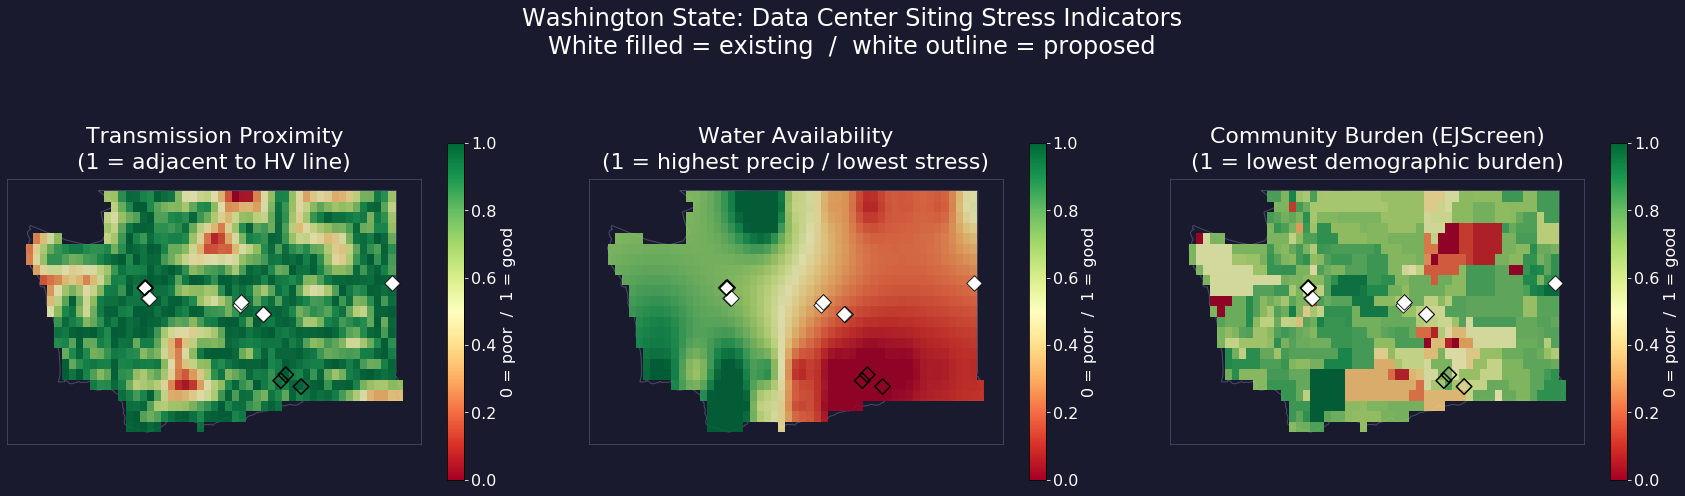

Saved to data/processed/indicators.png


In [9]:
DARK_BG = '#1a1a2e'
LAYER_CMAP = 'RdYlGn'
WHITE = 'white'

plt.rcParams.update({
    'text.color': WHITE,
    'axes.labelcolor': WHITE,
    'xtick.color': WHITE,
    'ytick.color': WHITE,
    'font.size': 18,
})

layers = [
    ('tx_score',    'Transmission Proximity',     '(1 = adjacent to HV line)'),
    ('water_score', 'Water Availability',          '(1 = highest precip / lowest stress)'),
    ('ej_score',    'Community Burden (EJScreen)', '(1 = lowest demographic burden)'),
]

fig, axes = plt.subplots(1, 3, figsize=(24, 9), facecolor=DARK_BG)

for ax, (col, title, subtitle) in zip(axes, layers):
    ax.set_facecolor(DARK_BG)
    wa.boundary.plot(ax=ax, color='#4a4a6a', linewidth=1.0, zorder=1)
    n_before = len(fig.axes)
    grid.plot(column=col, ax=ax, cmap=LAYER_CMAP, vmin=0, vmax=1,
              legend=True, legend_kwds={'shrink': 0.65, 'label': '0 = poor  /  1 = good'},
              alpha=0.85, zorder=2)
    if len(fig.axes) > n_before:
        cb_ax = fig.axes[-1]
        cb_ax.tick_params(labelsize=16, colors=WHITE)
        cb_ax.yaxis.label.set_color(WHITE)
        cb_ax.yaxis.label.set_size(16)
    _rep = dc_gdf[dc_gdf['source'] == 'reported']
    _prop = dc_gdf[dc_gdf['source'] == 'proposed']
    ax.scatter(_rep.geometry.x, _rep.geometry.y,
               c=WHITE, s=120, marker='D', zorder=5,
               edgecolors='black', linewidths=0.8)
    ax.scatter(_prop.geometry.x, _prop.geometry.y,
               facecolors='none', s=120, marker='D', zorder=5,
               edgecolors='black', linewidths=1.5)
    ax.set_title(f'{title}\n{subtitle}', color=WHITE, fontsize=22, pad=10, linespacing=1.4)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#4a4a6a')

plt.suptitle('Washington State: Data Center Siting Stress Indicators\n'
             'White filled = existing  /  white outline = proposed',
             color=WHITE, fontsize=24, y=0.90)
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.savefig(PROCESSED / 'indicators.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved to data/processed/indicators.png')


### 6b. Composite Suitability Map

The composite score (40% transmission + 35% water + 25% EJ) with existing data center 
locations overlaid. The central thesis of this analysis: **the Quincy / East Wenatchee 
cluster, which represents Washington's dominant data center corridor, scores well on 
transmission proximity but poorly on water availability and is located in a region where 
grid expansion is already exhausted.** Better-scoring locations exist — primarily in the 
transition zone between eastern WA transmission access and western WA water availability.

This geographic tension is precisely why the state's Data Center Workgroup found that 
Washington's infrastructure is 'falling behind in expanding the clean energy 
infrastructure needed to meet growing electricity demands.'
([WA DOR Workgroup Report, Dec 2025](https://dor.wa.gov/sites/default/files/2025-12/2025DataCntrWrkgrpPrelimReport.pdf))

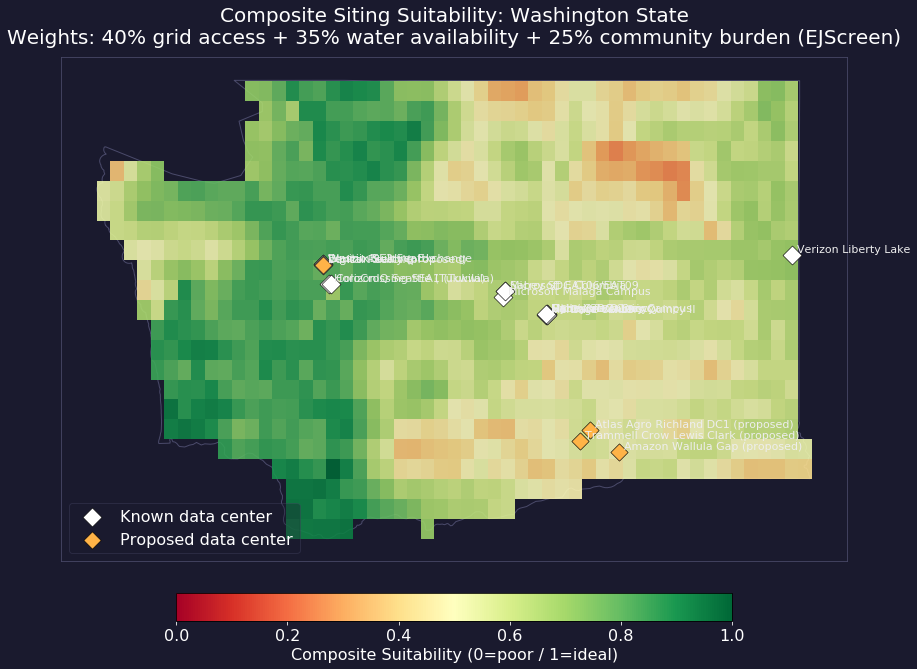

Saved to data/processed/composite_suitability.png


In [10]:
fig, ax = plt.subplots(figsize=(16, 10), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

plt.rcParams.update({
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'font.size': 18,
})

wa.boundary.plot(ax=ax, color='#4a4a6a', linewidth=1.0, zorder=1)

n_before = len(fig.axes)
grid.plot(
    column='composite', ax=ax,
    cmap='RdYlGn', vmin=0, vmax=1, alpha=0.88,
    legend=True,
    legend_kwds={
        'label': 'Composite Suitability (0=poor / 1=ideal)',
        'orientation': 'horizontal',
        'shrink': 0.5, 'pad': 0.05
    },
    zorder=2
)
if len(fig.axes) > n_before:
    cb_ax = fig.axes[-1]
    cb_ax.tick_params(labelsize=16, colors='white')
    cb_ax.xaxis.label.set_color('white')
    cb_ax.xaxis.label.set_size(16)

source_styles = {
    'reported':  ('white',  180, 'D', 'Known data center'),
    'proposed':  ('#FFB347', 150, 'D', 'Proposed data center'),
    'OSM':       ('#FF4444', 100, 'o', 'OSM data center'),
}
for source, (color, size, marker, label) in source_styles.items():
    grp = dc_gdf[dc_gdf['source'] == source]
    if len(grp) == 0:
        continue
    ax.scatter(grp.geometry.x, grp.geometry.y,
               c=color, s=size, marker=marker, zorder=6,
               edgecolors='black', linewidths=0.6, label=label)
    for _, row in grp.iterrows():
        ax.annotate(row['name'], (row.geometry.x, row.geometry.y),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=11, color='#eeeeee', zorder=7)

leg = ax.legend(loc='lower left', framealpha=0.35,
                facecolor=DARK_BG, edgecolor='#4a4a6a', fontsize=16)
for t in leg.get_texts():
    t.set_color('white')

ax.set_title(
    'Composite Siting Suitability: Washington State\n'
    'Weights: 40% grid access + 35% water availability + 25% community burden (EJScreen)',
    color='white', fontsize=20, pad=14
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_edgecolor('#4a4a6a')

plt.tight_layout()
plt.savefig(PROCESSED / 'composite_suitability.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved to data/processed/composite_suitability.png')


## 7. Summary Table: Existing Data Centers vs. Composite Score

How do the known data center locations score on each dimension? This table surfaces the 
core argument: the dominant cluster is optimized for one dimension (grid access) at the 
expense of the other two.

In [11]:
join_cols = ['tx_score', 'water_score', 'ej_score', 'composite', 'ann_precip_mm', 'geometry']
dc_full = gpd.sjoin(
    dc_gdf[['name', 'operator', 'source', 'geometry']],
    grid[join_cols],
    how='left', predicate='within'
)

display_cols = ['name', 'operator', 'tx_score', 'water_score', 'ej_score', 'composite', 'ann_precip_mm']
display_cols = [c for c in display_cols if c in dc_full.columns]
summary = dc_full[display_cols].copy()
for col in ['tx_score', 'water_score', 'ej_score', 'composite']:
    if col in summary:
        summary[col] = summary[col].round(3)
if 'ann_precip_mm' in summary:
    summary['ann_precip_mm'] = summary['ann_precip_mm'].round(0).astype('Int64')
    summary = summary.rename(columns={'ann_precip_mm': 'precip_mm_yr'})

print(summary.to_string(index=False))

                                name        operator  tx_score  water_score  ej_score  composite  precip_mm_yr
             Microsoft Quincy Campus       Microsoft     0.988        0.189     0.552      0.599           640
                        Vantage WA13         Vantage     0.988        0.189     0.552      0.599           640
                     CyrusOne Quincy        CyrusOne     0.988        0.189     0.552      0.599           640
                    Sabey SDC Quincy           Sabey     0.988        0.189     0.552      0.599           640
           H5 Data Centers Quincy II H5 Data Centers     0.988        0.189     0.552      0.599           640
                 Dell / Yahoo Quincy      Dell/Yahoo     0.988        0.189     0.552      0.599           640
               Microsoft EAT06/EAT09       Microsoft     0.985        0.293     0.636      0.656           790
             Microsoft Malaga Campus       Microsoft     0.985        0.293     0.636      0.656           790
 

## 8. Key Findings

1. **The Quincy / East Wenatchee cluster is grid-optimal but water-constrained.** High 
   transmission proximity scores reflect decades of infrastructure investment along the 
   Columbia River corridor. But annual precipitation in this region is ~200–350 mm/yr — 
   driest in the state — and the Columbia Basin's water allocation is fully subscribed. 
   Grant County's own administrator has stated that water and power are 'maxed out.'
   ([NPR / OPB, Aug 2025](https://www.npr.org/2025/08/17/nx-s1-5501579/washington-hydropower-data-center-boom-sustainability-climate-change))

2. **A transition zone exists.** The Cascades foothills — roughly the I-90 corridor from 
   Snoqualmie Pass toward Ellensburg, and the area east of Puget Sound — offer moderate 
   scores on all three dimensions simultaneously. No single indicator is maximized, but 
   no indicator is critically failed either.

3. **Western WA has high water availability but poses community burden risks in some areas.** 
   The Seattle metropolitan area scores well on EJ and water but the Seattle City Council 
   voted in June 2026 to impose a one-year moratorium on large data centers (>20 MW), 
   citing grid stress and land use pressure.
   ([Seattle City Council Blog, Apr 2026](https://council.seattle.gov/2026/04/30/councilmembers-introducing-moratorium-on-data-centers-in-seattle/))

4. **The weighting is a policy choice.** A commercial operator will weight transmission 
   proximity most heavily; a state planning agency concerned about HB 2515-style legislation 
   may weight water and EJ equally with grid access. The framework is designed to make 
   those tradeoffs explicit and transparent.

---

**Next notebook:** Add seismic hazard (USGS NSHM) and FEMA flood zones as risk-side 
modifiers, and validate the composite against the known locations of the 25 nationally 
canceled projects.

---
*Data sources: EPA EJScreen 2023, US Census TIGER/Line 2022, Open-Meteo ERA5 reanalysis, 
OpenStreetMap contributors (ODbL). Analysis: Simon Hansedasi / Edasi Motlev LLC.*